# 1. Keras 텍스트 전처리
    1. [수치 데이터로 변환] 텍스트 토큰화 및 정수 인코딩
    2. [같은 길이로 만들기] 패딩 (padding)

In [1]:
# tensorflow 설치 확인
import tensorflow
tensorflow.__version__

'2.10.0'

In [2]:
# 연습 샘플
texts = [
    "나는 학교에 간다",
    "너는 도서관에 간다",
    "그는 시장에 간다"
]
#texts = [ ["나", "학교", "가"], ["너", "도서관", "가"], ["그", "시장", "가"]]

## 1-1. 텍스트 데이터 Integer Encoding
- num_words = 사용할 단어 수 + 1

In [3]:
# Tokenizer 객체 생성 (특징 벡터용 단어 수와 OOV 토큰 지정)
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(num_words=5)

# 특징 집합 생성 및 정수 indexing
tokenizer.fit_on_texts(texts)
print(tokenizer.word_index)

# 입력 텍스트 리스트의 integer encoding
encoded_texts = tokenizer.texts_to_sequences(texts)
print(encoded_texts)

{'간다': 1, '나는': 2, '학교에': 3, '너는': 4, '도서관에': 5, '그는': 6, '시장에': 7}
[[2, 3, 1], [4, 1], [1]]


## 1-2. Padding : 입력 시퀀스의 길이를 동일하게 조정하기

In [4]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

padded_texts = pad_sequences(encoded_texts, padding='post')#, maxlen = 2)

print(padded_texts)

[[2 3 1]
 [4 1 0]
 [1 0 0]]


## 1-3. 정답 데이터 One-hot Encoding

In [5]:
label = [1, 0, 2, 5, 0, 2, 3]

from tensorflow.keras.utils import to_categorical

encoded_label = to_categorical(label)
encoded_label

array([[0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.]], dtype=float32)

# 2. 텍스트 전처리를 위한 파라미터 결정하기
- Integer Encoding을 위한 단어(특징) 집합의 크기 정하기 (Tokenizer의 num_words)
- Padding을 위한 시퀀스 길이 정하기 (pad_sequences의 max_len) 

In [6]:
# 데이터 로딩 및 실습 데이터 추출
import pandas as pd
texts = list(pd.read_csv('./data/Korean_movie_reviews_2016.csv').review)
len(texts),texts[:2]


(165384, ['부산 행 때문 너무 기대하고 봤', '한국 좀비 영화 어색하지 않게 만들어졌 놀랍'])

## 2-1. 단어 집합의 크기 정하기 (Tokenizer의 num_words)
등장 빈도수가 기준값(threshold)보다 적은 단어의 비중을 확인하여 정하기
1. corpus의 전체 단어 수 (total_cnt)와 전체 빈도수 (total_freq) 계산
2. threshold보다 빈도수가 적은 단어수 카운트 (rare_cnt)와 빈도수 (rare_freq) 계산
3. 희귀 단어의 비율(rare_cnt/total_cnt)과 희귀 등장 빈도 비율 계산(rare_freq/total_freq)
4. 희귀 단어를 뺀 단어 수 -> 단어 집합의 크기 산정

In [ ]:
# Tokenizer로 단어-빈도 사전 생성
test_tokenizer = Tokenizer()
test_tokenizer.fit_on_texts(texts)

In [ ]:
# 등장 빈도수가 threshold회 미만인 단어들이 이 데이터에서 얼만큼의 비중을 차지하는지 확인
threshold = 9

#   단어, 빈도수를 받아서 빈도수가 threshold보다 작으면 rare_cnt, rare_freq에 update
from mylib.my_utils import cnt_word

#tokenizer.word_counts.items

total_cnt, rare_cnt, total_freq, rare_freq = cnt_word(test_tokenizer, threshold)

전체 단어 :  52,011개  1,888,659번
희귀 단어 (등장빈도 9번 이하) :  40,153개  86,465번
희귀 단어 비율 : 단어 수 77.20%/빈도 수 4.58%
희귀 단어를 제외한 단어 수 : 11,858개 95.42%


## 2-2. Padding 길이 정하기 (pad_sequences의 max_len)
1. 단어 길이 데이터로 DataFrame 생성
2. 분포 시각화 : DataFrame의 Histogram 시각화 (df.hist())
3. 단어 길이 통계 정보 확인 (df.describe())
4. 텍스트의 길이가 설정한 max_len 이하인 비율 계산

In [9]:
#단어 길이 데이터로 DataFrame 생성  (리스트 → DataFrame)
import pandas as pd
len_list = [len(text.split()) for text in texts]
let_df = pd.DataFrame(len_list, columns = ['length'])
let_df

,length
0,6
1,7
2,10
3,31
4,19
...,...
165379,14
165380,7
165381,8
165382,13


In [10]:
texts[0]

'부산 행 때문 너무 기대하고 봤'

In [11]:
let_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165384 entries, 0 to 165383
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   length  165384 non-null  int64
dtypes: int64(1)
memory usage: 1.3 MB


array([[<Axes: title={'center': 'length'}>]], dtype=object)

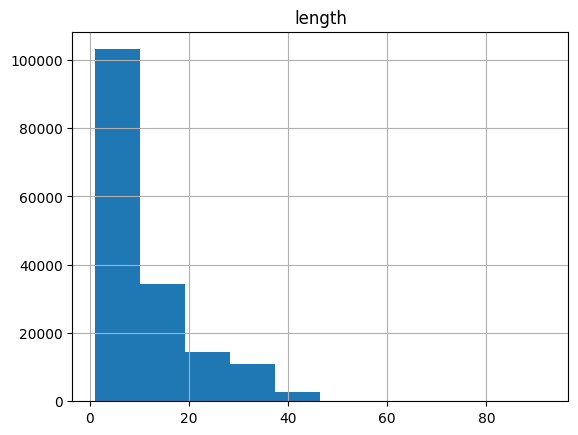

In [12]:
# 분포 시각화 : DataFrame의 Histogram 시각화 (df.hist())
let_df.hist()

In [13]:
#단어 길이 통계 정보 확인 (df.describe())
let_df.describe()

,length
count,165384.000000
mean,11.419841
std,9.117849
min,1.000000
25%,5.000000
50%,8.000000
75%,15.000000
max,92.000000


In [14]:
#텍스트의 길이가 설정한 max_len 이하인 비율 계산
from mylib.my_utils import below_threshold_len

max_len = 60
below_threshold_len(max_len, texts)

길이가 60 이하인 text의 비율 : 100.00%
